In [1]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [data.data,
     data.target.rename("MedHouseVal")],
)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,NaN
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,NaN
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,NaN
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,NaN
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 41280 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 3.1 MB


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
df.isnull().sum()

MedInc         20640
HouseAge       20640
AveRooms       20640
AveBedrms      20640
Population     20640
AveOccup       20640
Latitude       20640
Longitude      20640
MedHouseVal    20640
dtype: int64

In [6]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [8]:
print(df.shape)

(20640, 9)


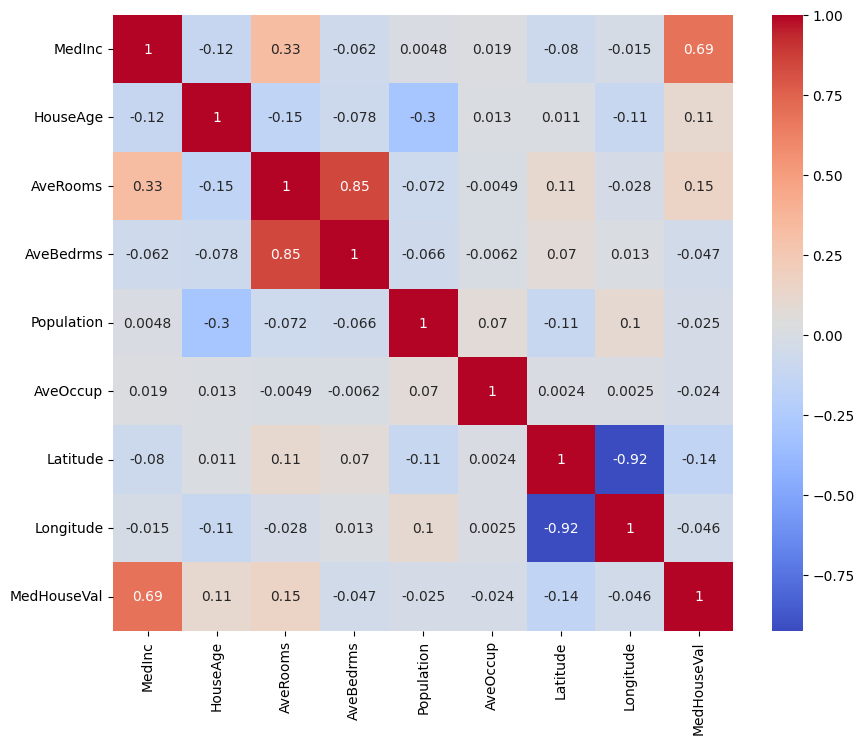

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

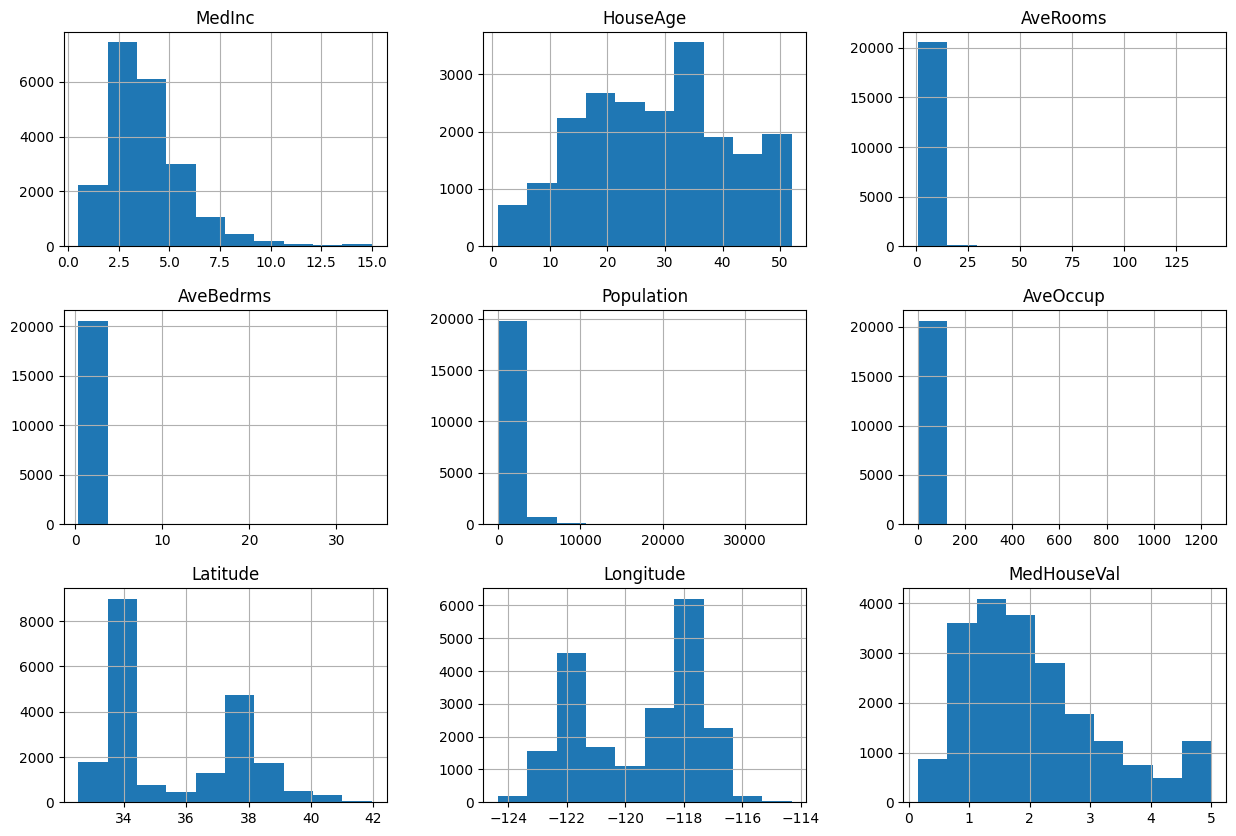

In [10]:
df.hist(figsize=(15,10))
plt.show()

In [11]:
x = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print(x.shape)
print(y.shape)

(20640, 8)
(20640,)


In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)

x_train: (16512, 8)
x_test: (4128, 8)


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train,y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [14]:
y_pred = model.predict(x_test)
print(y_pred[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)
r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("RMSE =", rmse)
print("R2 Score =", r2)

MAE = 0.5332001304956557
RMSE = 0.7455813830127758
R2 Score = 0.5757877060324514


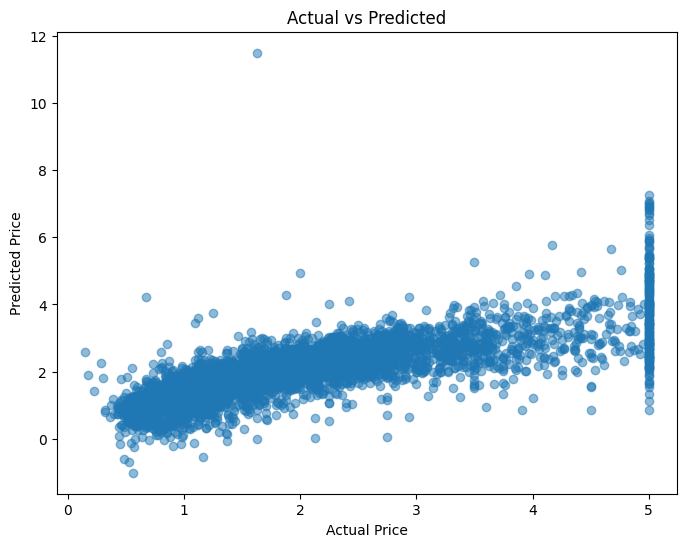

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

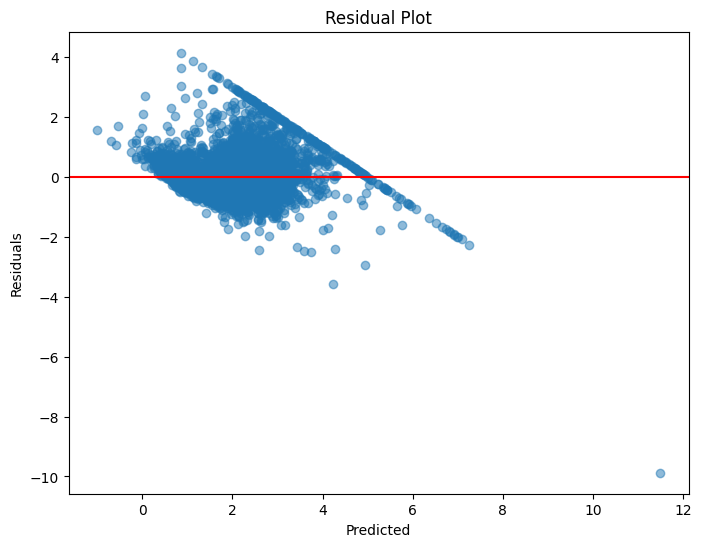

In [17]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)
plt.axhline(y=0,color='red')

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [18]:
import pickle
pickle.dump(
    model,
    open("house_price_model.pkl","wb")
)